In [1]:
import sys

sys.path.insert(0, "../..")

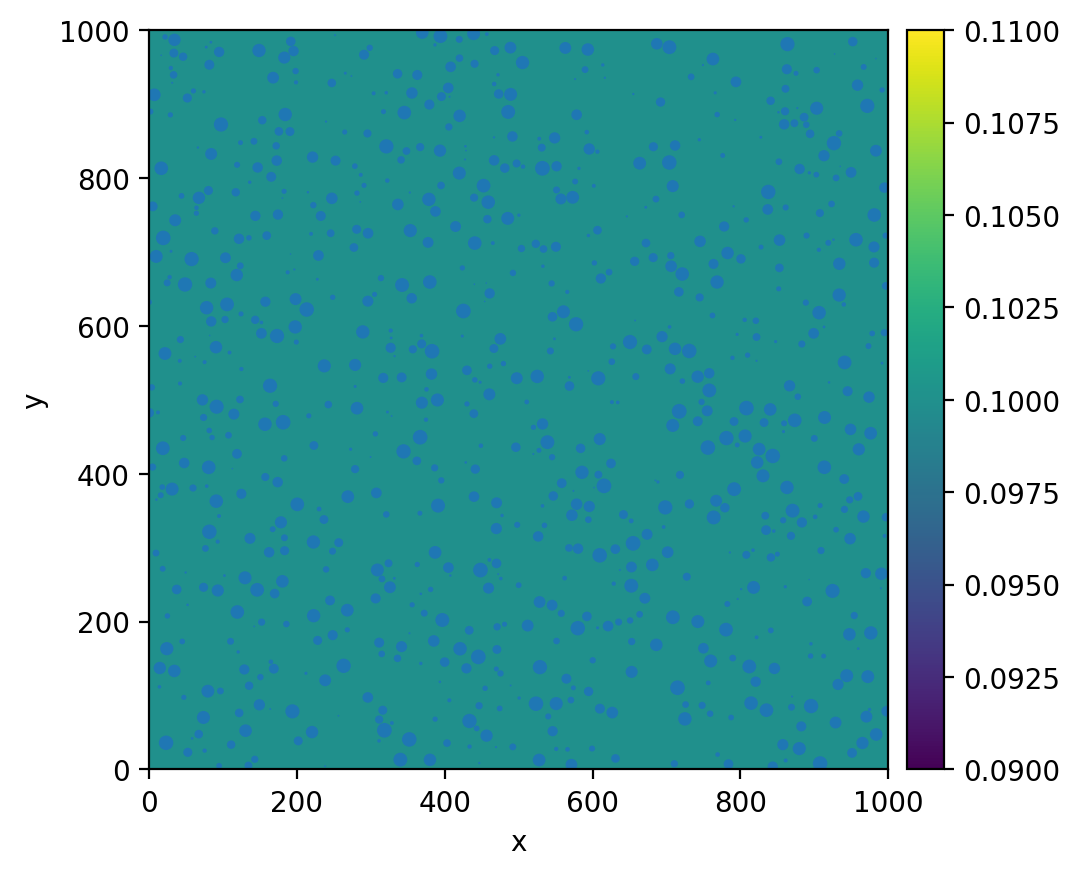

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from droplets import Emulsion
from pde import CartesianGrid, ScalarField

import sim

rng = np.random.default_rng(1)

# set up initial state
grid = CartesianGrid([[0, 1000], [0, 1000]], 128, periodic=True)
background = sim.ScalarFieldElement.from_field(ScalarField(grid, 0.1))
droplet_data = Emulsion.from_random(1000, grid, radius=(1, 10), rng=rng)
droplets = sim.SphericalDropletsElement.from_droplets(droplet_data)
state = sim.State(
    {"background": background, "droplets": droplets},
    parameters={"bounds": grid.axes_bounds},
)
state.plot()


In [14]:
# set up simulation
simulation = sim.Simulation(state)
simulation.add_actor("background", sim.DiffusionActor())
droplet_actor = sim.SphericalDropletActor({"equilibrium_concentration": "1 / radius"})
simulation.add_actor(("droplets", "background"), droplet_actor)


In [15]:

# run simulation
tracker = sim.DropletElementTracker("droplets", interrupts=1000)
result = simulation.run(t_range=50_000, tracker=["progress", tracker])

  0%|          | 0/50000.0 [00:00<?, ?it/s]

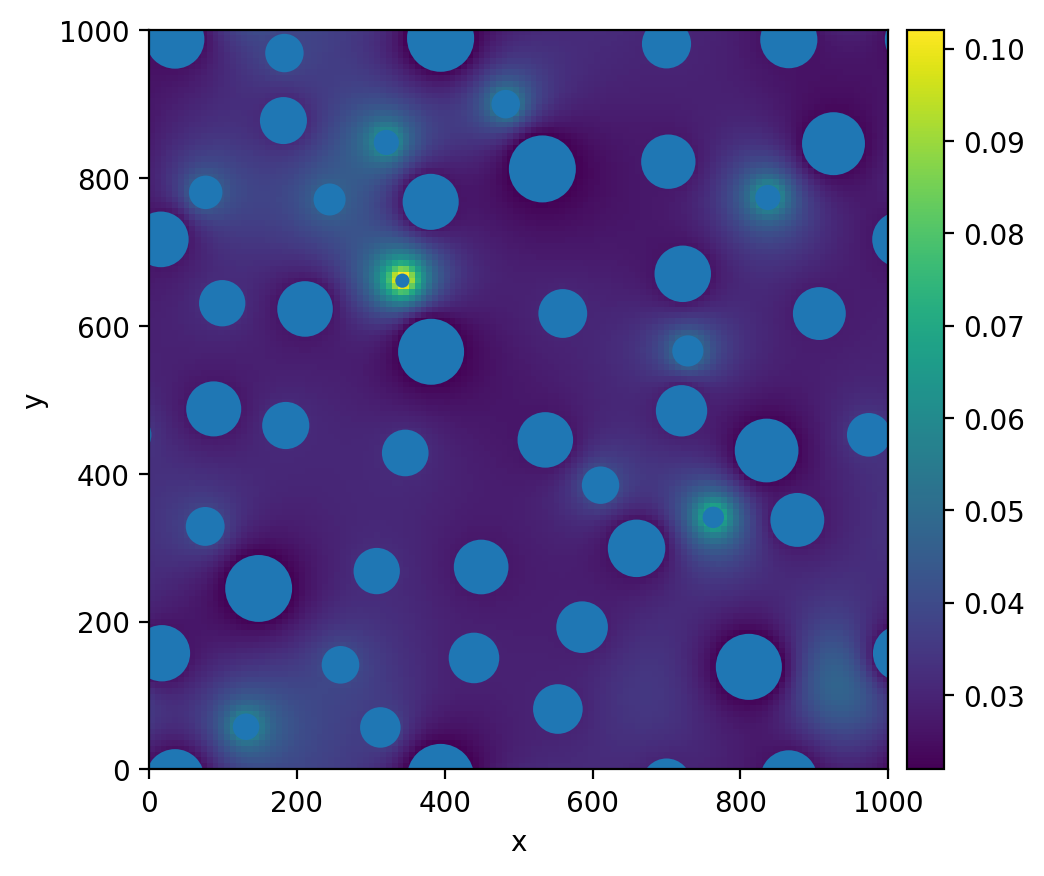

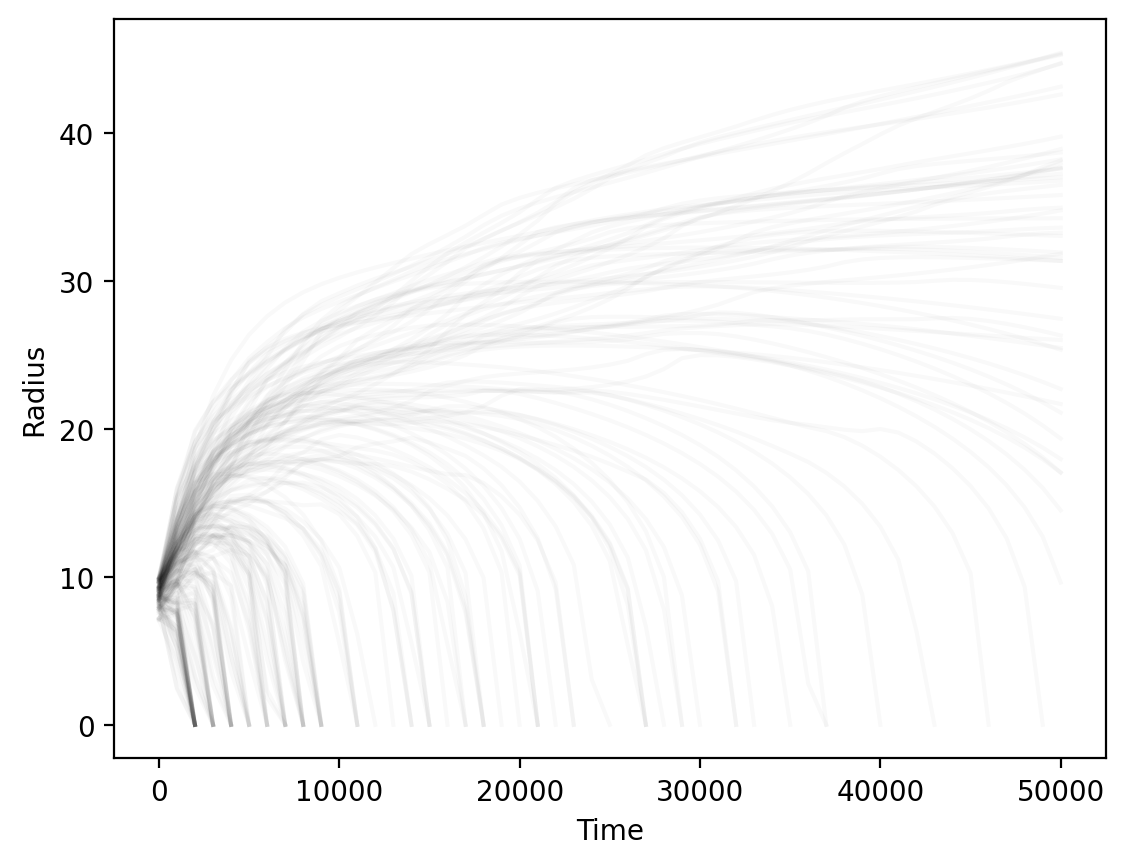

In [16]:
result.plot(element_args={"droplets": {"grid": grid}})
tracker.droplet_tracks.plot()

In [17]:
result.plot(element_args={"droplets": {"grid": grid}}, action="none")
plt.tight_layout()
plt.savefig("last_state.pdf")

In [18]:
tracker.droplet_tracks.plot(action="none")
plt.tight_layout()
plt.savefig("radii_time.pdf")

In [7]:
rows = [
    {"t": t, **emulsion.get_size_statistics()}
    for t, emulsion in zip(tracker.emulsions.times, tracker.emulsions)
]
df_stats = pd.DataFrame(rows)

Text(0, 0.5, 'Mean radius')

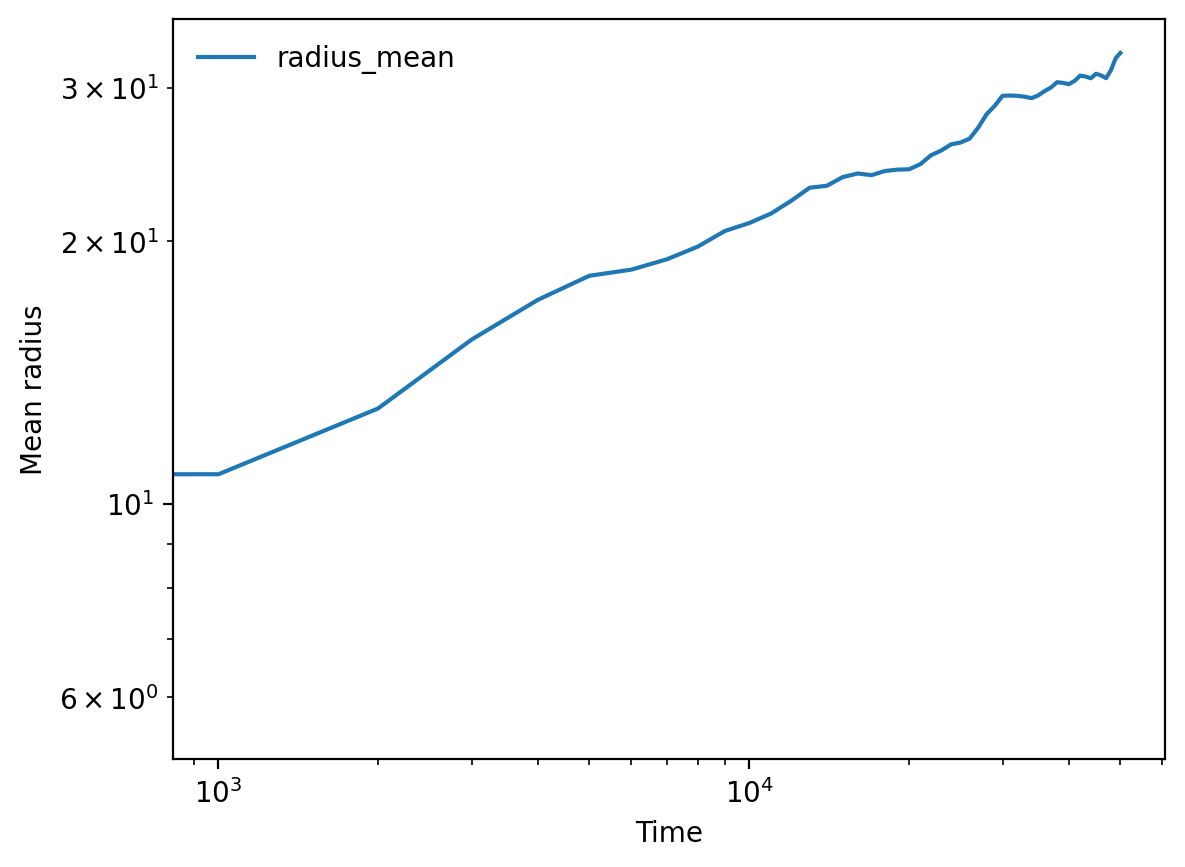

In [8]:
df_stats.plot("t", "radius_mean")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Time")
plt.ylabel("Mean radius")